# Loading gravitatational-wave data from SFDBs and running the Hough transform


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/andrew-l-miller/gwosc/blob/main/create_sfdbs/searching_and_injecting_with_SFDBs_and_FH.ipynb)


In [1]:
from pathlib import Path
import os
import requests
import argparse
import matplotlib.pyplot as plt
import numpy as np
import scipy
import glob
import importlib


In [2]:
import pyhough
importlib.reload(pyhough)
import pyfstat
from read_sfdb import *
from pyhough import pm
from pyhough import hm
from pyhough import physics
from pyhough import gfh
from pyhough.provider_injections import *
from pyhough.signal_simulations import *
from pyhough.inject import *
from pyhough.FFTing import test_exp_dist, calc_dsfact, get_sft_sps_and_f_inds,get_downsampled_times_samps
from pyhough.time_conversions import *


26-02-25 07:51:21.435 pyfstat INFO    : Running PyFstat version 2.0.2
8.326651578609017


### what the SDFB header contains

`SFDBheader:
  eof             = 0
  endian          = 1.0
  detector        = 2
  gps_sec         = 1369185280
  gps_nsec        = 0
  tbase           = 1024.0
  firstfrind      = 0
  nsamples        = 2097152
  red             = 128
  typ             = 2
  n_flag          = -1.0
  einstein        = 1.0
  mjdtime         = 60091.05164351852
  nfft            = 7
  wink            = 5
  normd           = 7.62939453125e-06
  normw           = 1.2066189050674438
  frinit          = 0.0
  tsamplu         = 0.000244140625
  deltanu         = 0.0009765625
  vx_eq           = 1.22345e-319
  vy_eq           = 4.015697475586e-312
  vz_eq           = 0.0
  px_eq           = 1.034068651e-314
  py_eq           = 2.068136562e-314
  pz_eq           = 3.1022049663e-314
  n_zeroes        = 0
  sat_howmany     = 0.0
  spare1          = 0.0
  spare2          = 0.0
  spare3          = 0.0
  spare4          = 0.0
  spare5          = 0.0
  spare6          = 0.0
  lavesp          = 16384
  spare8          = 1
  spare9          = 0`

In [3]:
!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt
!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt



File 'segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt' already there; not retrieving.

File 'segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt' already there; not retrieving.



In [4]:
obs_run = 'O4a'
ifo = 'H1'
fname_scisegs_for_sfdbs = ifo+'_'+obs_run+'_sciseg_for_sfdb.txt'
from convert_sciseg_file import load_sciseg_file,time_in_science


if obs_run == 'O4a':
    if ifo == 'H1':
        O4a_scisegs = 'segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt'
    elif ifo == 'L1':
        O4a_scisegs = 'segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt'

sci_times = load_sciseg_file(O4a_scisegs)

## Main CW injection piece

In [7]:
sfdb_files = glob.glob("/Users/andrewmiller/Downloads/*.SFDB09")

if not sfdb_files:
    raise FileNotFoundError("No .SFDB09 files found in the current directory.")
else:
    sfdb_file = sfdb_files[0]
    print(f"Using SFDB file: {sfdb_file}")
minf = 1205
maxf = minf + 1

allt0s = []
spec_rows = []   # list of 1D arrays (each is eq_power or band-cut)
all_vsss = []   # will become (3, N)
all_psss = []
fft_index = 0
inj_flag = True
downsamp = True
fmean = (maxf + minf)/2
h0=2e-24
fdot=-1e-7
position = [50., -20.] ## alpha,delta


np.random.seed(5678)

max_num_ffts = 100

inj_provider = provider_cw(f0=fmean, fdot=fdot, alpha=position[0], delta=position[1], h0=h0)
# inj_provider = provider_sinusoid(f0=fmean, h0=h0)
# inj_provider = provider_sinusoid_drift(f0=fmean, fdot=fdot, h0=h0)

ant = ligoh()
nsid=10000

alpha,delta = random_sky_deg()
psi = random_psi()
cosiota = random_cosiota()
sour = Source(alpha,delta,psi,cosiota)
sid1 = np.real(sidereal_lf_series(position[0], position[1], 0.0, 0.0, ant, nsid))
sid2 = np.real(sidereal_lf_series(position[0], position[1], 0.0, 45.0, ant, nsid))
SD = 86164.09053083288; #sidereal day


with open(sfdb_file, "rb") as f:
    while True:
        sfdb_head, _, sps, sft = sfdb_read_an_FFT(f)
        if sfdb_head == 0:
            break
        if fft_index == 0:
            t0 = sfdb_head.gps_sec
            dt = sfdb_head.tsamplu
            tfft = sfdb_head.tbase
            nsam = sfdb_head.nsamples
            df = sfdb_head.deltanu
            red = sfdb_head.red

            
            freqs = np.arange(nsam) * df
            times = np.arange(nsam) * dt * 2 ## times 2 b/c simulating complex signal --> f_nyg = f_samp
            norm_factor = sfdb_head.normd * sfdb_head.normw * np.sqrt(2)
            all_t0s_in_sfdb = np.arange(max_num_ffts)*tfft/2+t0
            vs = get_detector_velocities(all_t0s_in_sfdb,tfft,ifo)
 
            ctx = InjContext(vs=vs,sid1=sid1,sid2=sid2,source=sour)
            k1, k2, fr1, fr2, *_ = get_sft_sps_and_f_inds(minf, maxf, nsam, df, red, dsfact=1.0)

        sps_full = np.repeat(sps, red) / norm_factor
        
        if inj_flag:
            mjd_time = gps2mjd(sfdb_head.gps_sec)

            if downsamp:
                # Downsampled injection uses only the [k1:k2] band
                dsfact, NORM = calc_dsfact(dt, minf, maxf)

                sft_band = sft[k1:k2]
                nfftnew = k2 - k1

                # dtnew determined by your helper (must match your change_FFT_length logic)
                dtnew, _ = get_downsampled_times_samps(dt, nsam, dsfact, sft_band)

                inj_times = np.arange(nfftnew) * dtnew

                # sidereal time samples (hours) on SAME grid
                st = gmst(mjd_time) + dtnew * (86400.0 / SD) * np.arange(nfftnew) / 3600.0

                # absolute time used by phase model
                tt = inj_times + (sfdb_head.gps_sec - t0)

                amps, fsss = inj_provider(tt, fft_index, ctx)

                # match change_FFT_length downsamp branch: band-relative freq
                fsss = fsss - fr1

                phase_evol = phase_from_frequency(tt, fsss)

                i1 = np.mod(np.floor(st * (nsid - 1) / 24.0 + 0.5).astype(int), nsid - 1)
                sid1_t = ctx.sid1[i1]
                sid2_t = ctx.sid2[i1]

                sig_t = amps * (sour.Hp() * sid1_t + sour.Hc() * sid2_t) * np.exp(1j * phase_evol)

                # inject into band only
                sft[k1:k2] = inject_sig_into_sft(sig_t, sft_band, NORM)

            else:
                # Non-downsampled injection uses the full stored one-sided SFT
                # Your convention: analytic signal sampled at 2*dt with length nsam (= nfft/2)
                NORM = 1.0

                st = gmst(mjd_time) + dt * (86400.0 / SD) * np.arange(nsam) / 3600.0

                tt = times + (sfdb_head.gps_sec - t0)

                amps, fsss = inj_provider(tt, fft_index, ctx)
                phase_evol = phase_from_frequency(tt, fsss)

                i1 = np.mod(np.floor(st * (nsid - 1) / 24.0 + 0.5).astype(int), nsid - 1)
                sig_t = amps * (sour.Hp() * ctx.sid1[i1] + sour.Hc() * ctx.sid2[i1]) * np.exp(1j * phase_evol)

                # inject into full SFT, then (optionally) slice later when building the band spectrogram
                sft = inject_sig_into_sft(sig_t, sft, NORM)
       
        if (np.sum(sps_full) == 0) or (np.sum(np.abs(sft)) == 0):
            eq_power = np.zeros((np.shape(sps_full)))
        else:
            eq_power = np.abs(sft)**2 / sps_full ** 2
        
        in_band = (freqs >= minf) & (freqs <= maxf)
        spec_rows.append(eq_power[in_band])
        
        allt0s.append(sfdb_head.gps_sec)
        fft_index += 1

        

spec = np.vstack(spec_rows).T  # shape: (nfreq_in_band, ntime)
allt0s = np.array(allt0s)
band_freqs = freqs[in_band]
t_rel = allt0s - allt0s[0]
print('DONE')


Using SFDB file: /Users/andrewmiller/Downloads/H1_GWOSC-4KHZ_R1_STRAIN_20230527_002310.SFDB09
26-02-25 07:52:09.474 pyfstat.utils.ephemeris INFO    : No /Users/andrewmiller/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.
DONE


In [8]:
threshold = 2.5
pm_times,pm_freqs,pm_pows,index = pyhough.pm.make_peakmap_from_spectrogram(allt0s,band_freqs,spec,threshold)

(1205.3, 1205.7)

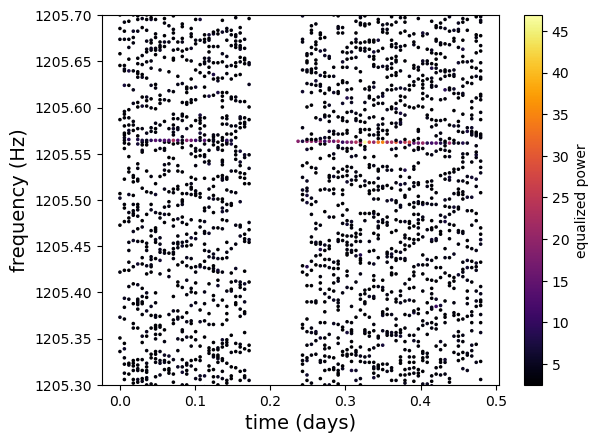

In [9]:
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,pm_freqs,pm_pows,'.',label='equalized power')

plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);
plt.ylim(1205.3,1205.7)

## Doppler correct the peakmap

In [10]:
Nts = len(allt0s)
vec_n = pyhough.pm.astro2rect(position,1)
vs = get_detector_velocities(allt0s,tfft,ifo)
freqs_new=pyhough.pm.remove_doppler_from_peakmap(pm_times,pm_freqs,index,vec_n,vs.T,Nts)
# freqs_new=pm_freqs

26-02-25 07:52:16.482 pyfstat.utils.ephemeris INFO    : No /Users/andrewmiller/.pyfstat.conf file found. Will fall back to lal's automatic path resolution for files [earth00-40-DE405.dat.gz,sun00-40-DE405.dat.gz]. Alternatively, set 'earth_ephem' and 'sun_ephem' class options.


## Plot Doppler-corrected peakmap

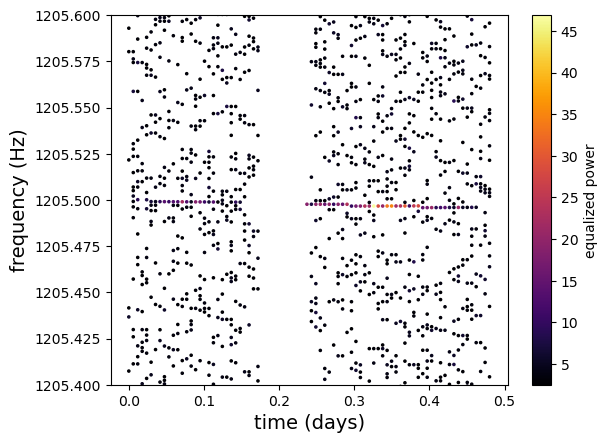

In [12]:
pyhough.pm.python_plot_triplets((pm_times-pm_times[0])/86400,freqs_new,pm_pows,'.',label='equalized power')

plt.xlabel('time (days)',size=14)
plt.ylabel('frequency (Hz)',size=14);
plt.ylim((1205.4,1205.6));

## Set up parameters to do FH

In [13]:
df = 1/tfft # the frequency bin size
Tobs = np.max(allt0s-allt0s[0]) # the duration of the peakmap in seconds
ref_perc_time = 0.5 * 100 # reference time for the Hough at which f0 is determined, set any number between 0 (beginning), 100 (end)
dsd = 1/(tfft*Tobs) # step in spin-down: dsd = df / Tobs
# sdgrid = pyhough.hm.make_sd_grid(sig_fdot,dsd) ## grid of spin-downs to search over
min_fdot_search = -10 * dsd
max_fdot_search = 10 * dsd 
sdgrid = np.arange(min_fdot_search,max_fdot_search,dsd)

## Run FH

In [14]:
hmap_from_pm = pyhough.hm.hfdf_hough(pm_times,freqs_new,tfft,sdgrid,ref_perc_time)
fs_for_hmap_from_pm = np.arange(np.min(freqs_new),np.max(freqs_new),df)

## Plot Hough map

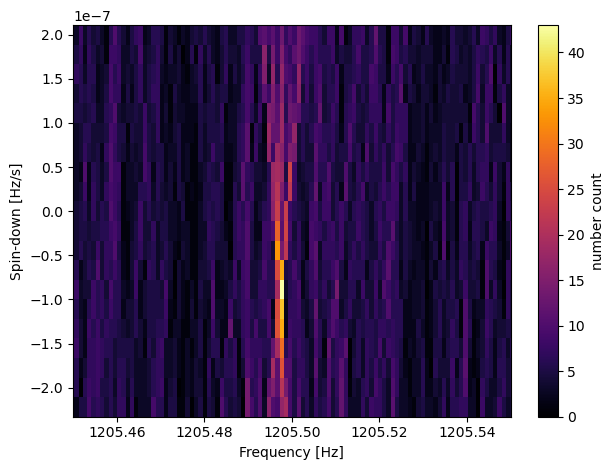

In [15]:
fig, ax = plt.subplots()#figsize=(0.8 * 16, 0.8 * 9))
ax.set(ylabel="Spin-down [Hz/s]", xlabel=r"Frequency [Hz]")#, ylim=(99.98, 100.02))
c = ax.pcolormesh(
    fs_for_hmap_from_pm,
    sdgrid,
    hmap_from_pm,
    cmap="inferno",
    shading="nearest",
)
fig.colorbar(c, label="number count")
plt.tight_layout()
# ax.set(ylim=(sig_fdot*1.3,-0.7e-9));
ax.set(xlim=(1205.45,1205.55));
# plt.ylim([1205.4,1205.6])

# plt.savefig('hm_map.jpg',format='png',dpi=400)

In [17]:
!pwd

/Users/andrewmiller/Desktop/China/gwosc/gwosc/create_sfdbs


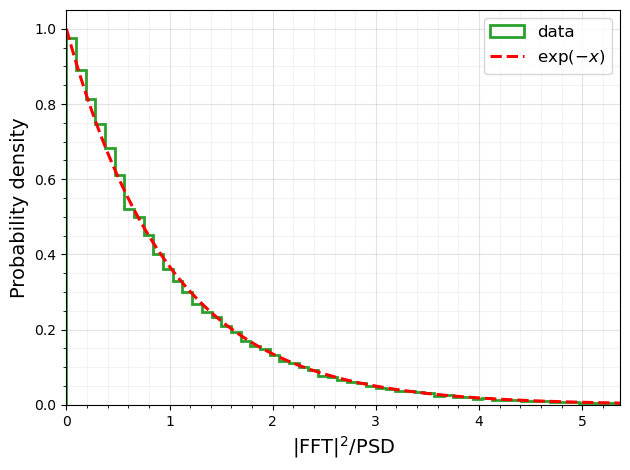

mean: 0.9926177409239143
std: 1.097889402196557
median: 0.6722851693630219


In [16]:
test_exp_dist(spec.flatten()[spec.flatten()>0],500)